In [1]:
using LinearAlgebra
using Plots

# For cumputing the mean value of a numerical vector:
avg(x) = sum(x)/length(x) 

avg (generic function with 1 method)

## [About Clustering (se VMLS chapter 4)](https://web.stanford.edu/~boyd/vmls/vmls.pdf#page=79)
**Updated by U.I. 12.04.2025**
### 4.1 Clustering
Suppose we have $N$ $n$-vectors, $x_1, \dots, x_N$. The goal of *clustering* is to partition the vectors into $k$ clusters (groups), with the vectors in each group close to each other. Clustering is widely used in many application areas where the vectors represent features of objects subject to clustering.

Normally we have $k$ much smaller than $N$ meaning that there are many more vectors than groups. Typical applications use values of $k$ that range from a handful to a few hundred or more, with values of $N$ that range from hundreds to billions. Part of the task of clustering a collection of vectors is to determine if it is useful to partition the vectors into $k$ groups, so that vectors in each cluster are relatively near each other. Of course, this depends on $k$ (the number of clusters) and the particular data, $i.e.$, the vectors $x_1, \dots, x_N$.


### 4.2 The k-means clustering objective

In Julia, we can store a collection of $N$ vectors (samples) in a list or tuple called `x` (or some other suitable name). We can access the `i`th entry of `x` (which is a vector) using `x[i]`. To specify an assignment for each of the $N$ samples to one of the $k$ clusters, we can use a list of cluster labels called `c`, where `c[i]` refer to the number (label) of the cluster that the vector `x[i]` is associated with.<br> 
(This is an integer between $1$ and $k$ when $k$ clusters are considered.) 

(In [VMLS chapter 4](https://web.stanford.edu/~boyd/vmls/vmls.pdf#page=79), the cluster labels (assignments) are kept in the vector `c`, or alternatively we consider the vectors `x[i]` assigned to the subsets $G_j,\ (1\leq j\leq k)$. contain the the indices of the vectors associated with cluster $j$.) We can store the $k$ cluster centers (cluster representatives) as a Julia list called `z`, where `z[j]` is the vector representing the `j`th cluster center. (In VMLS we denote the cluster centers as the vectors $z_1,\ . . . ,\ z_k$.)

__The clustering objective function__ (for comparing the goodness of alternative clustering solutions - to be minimized during the clustering process) is given by $$J^{clust}(x, c, z)=\frac{1}{N}\sum_{i=1}^N\|x_i-z_{c_i}\|^2,$$
and can be evaluated by the following Julia-function:

In [2]:
Jclust(x,z,c) = avg( [norm(x[i]-z[c[i]])^2 for i=1:length(x)] )

Jclust (generic function with 1 method)

In [3]:
x = [ [0,1], [1,0], [-1,1] ]   # vectors
z = [ [1,1], [0,0] ]           # the cluster representatives (k=2)
c = [1, 2, 1]                  # the cluster labels associated with the vectors in x
[x,z,c]

3-element Vector{Vector}:
 [[0, 1], [1, 0], [-1, 1]]
 [[1, 1], [0, 0]]
 [1, 2, 1]

The objective function value assocoated with $x$, $z$ and $c$:

In [4]:
Jclust(x,z,c)

2.0

The objective function value assocoated with an alternative labelling $x$, $z$ and $c_{alt}$:

In [5]:
c_alt = [1,1,2]; # An alternative labelling of the vectors in x
Jclust(x,z,c_alt)

1.3333333333333333

### 4.3 The k-means problem and -algorithm

For a set of $N$ vectors stored in $x$, and a specified integer $k\geq 2$ of desired clusters, we seek a set of $k$ cluster centers to be held in $z$ and an associated labelling $c$ of the vectors in $x$ that minimizes $J^{clust}(x, c, z)$. This is __the [$k$-means clustering problem](https://en.wikipedia.org/wiki/K-means_clustering)__. 

Unfortunately, there is **no known strategy for global minimization** of $J^{clust}(x, c, z)$ w.r.t $c$ and $z$ for $k\geq 2$, so **we have to turn to heuristics** in the search for good solution candidates.

Below, we provide a simple Julia function implementing the [naive $k$-means algorithm](https://en.wikipedia.org/wiki/K-means_clustering#Standard_algorithm_(naive_k-means)) and apply it to a set of points in a plane, similar to the example in [Figure 4.1 on page 70 in VMLS](https://web.stanford.edu/~boyd/vmls/vmls.pdf#page=80). 

We first create a function `kmeans_` that can be called as `c, z = kmeans_(x, k)` where `x` is an array of $N$ vectors and `k` is the number of groups. The first output argument `c` is an array of `N` integers, containing the computed group assignments (integers from $1$ to $k$). The second output argument `z` is an array of `k` vectors, with the `k` group representatives (cluster centers). We also include two optional keyword arguments, with a limit on the number of iterations (`maxites`) and a tolerance (`tol`) used in the stopping condition fo the algorithm.

In [ ]:
# Change notation to c and z (instead of assignment and reps)
using Random #, StatsBase
function kmeans_(x, k; maxiters = 100, tol = 1e-5) 
    # Overriding the "error in method definition: function VMLS.kmeans must be explicitly imported to be extended"  
    # By writing kmeans_ instead of kmeans to display this implementation                                           
    # INPUTS:  x - a set of vectors, k - the number of clusters to be calculated, maxiters - the maximum number 
    #          of iterations in the algorithm, tol - the (relative) tolerance limit for convergence.
    # OUTPUTs: c - cluster labels assigned for each sample, z - the (k) cluster centers, J - the objective 
    #          function values for each cluster iteration.
    N = length(x)     # Number of samples (vectors in x) 
    d = length(x[1])  # Dimension of the sample vectors.
    distances = zeros(N) # Used to store the distance of each sample to the nearest representative.
    #z = copy([x[i] for i in sample(1:N, k, replace=false) ]) # Initial cluster centers as random samples from data.                                                                                                        
    z = copy([x[i] for i in randperm(N)[1:k]]) # Initial cluster centers as random samples from data.      
    
    Js = zeros(maxiters);  # For storing the objective function values of the process.                                                                           #  9
    c = zeros(Int, N)      # Vector for assigning cluster memberships

    
    Jprevious = Inf          # used in stopping condition below
    for iter = 1:maxiters 
        for i = 1:N          # For each x[i], find distance to the nearest representative and update its cluster number. 
            (distances[i], c[i]) =  findmin([norm(x[i] - z[j]) for j = 1:k]) 
        end; 
        
        # Compute clustering objective value for distances of the current clustering.
        J = distances'*distances/N  # =sum(distances.^2)/N 
        Js[iter] = J; 
    
        # Center of cluster j set to average of the samples points in updated cluster j.
        for j = 1:k 
            cj = [i for i=1:N if c[i] == j] # find the indices of the samples associated with cluster j 
            z[j] = sum(x[cj]) / length(cj); # the updated center of cluster j (the mean of the associated samples)
        end;        
    
        # Show progress and terminate if J stops decreasing or maximun number of iterations.
        println("Iteration ", iter, ": Jclust = ", J, ".") 
        if (iter > 1 && abs(J - Jprevious) < tol * J) || iter == maxiters 
            Js = Js[1:iter]; 
            return c, z, Js  
        end 
        Jprevious = copy(J)
    end 
    
end 

kmeans_ (generic function with 1 method)

In [7]:
zeros(Int,10)

10-element Vector{Int64}:
 0
 0
 0
 0
 0
 0
 0
 0
 0
 0

**Initialization.** As discussed in [VMLS (page 76)](https://web.stanford.edu/~boyd/vmls/vmls.pdf#page=86), the k-means algorithm can start from a random initial choice of representatives (in $z$), or from a random assignment of the points in `k` groups (in $c$). In the above implementation, we use the second option (`line 11`). The Julia function `rand(1:k)` picks a random number from the set `1:k`, i.e., the integers `1, . . . , k`. On `line 11` we create an array assignment of $N$ elements, with each element chosen by calling `rand(1:k)`. 

**Updating group representatives.** `Lines 17–20` update the `k` group representatives. In `line 18`, we find the indexes of the points in cluster `j` and collect them in an array group. The expression `x[group]` on `line 19` constructs an array from the subset of elements of `x` indexed by group. The function sum computes the sum of the elements of the array `x[group]`. Dividing by the number of elements length(`x[group]`) gives the average of the vectors in the group. The result is `j`th the group representative. This vector is stored as the `j`th element in an array `reps` of length `N`. 

**Updating group assignments.** On `lines 24–27` we update the group assignments. The Julia function `findmin` computes both the minimum of a sequence of numbers and the position of the minimum in the sequence. The result is returned as a `2 - tuple`. On `lines 25–26`, we apply `findmin` to the array of `k` distances of point `x[i]` to the k representatives. We store the distance to the nearest representative in `distances[i]`, and the index of the nearest representative (i.e., the new assignment of point `i`) in `assignment[i]`. 

**Clustering objective.** On `line 30` we compute the clustering objective `Jclust` (see above and [equation (4.1) on page 72 in VMLS](https://web.stanford.edu/~boyd/vmls/vmls.pdf#page=82)) as the square of the RMS value of the vector of distances. 

**Convergence.** We terminate the algorithm when the improvement in the clustering objective becomes very small (`lines 34–36`). 

**Example.** We apply the algorithm on a randomly generated set of `N = 300` points, shown in Figure 4.1. These points were generated as follows.

In [8]:

# Alternatively:
X = [[ 0.3*randn(2) for i = 1:100 ];
[ [1,1] + 0.3*randn(2) for i = 1:100 ];
[ [1,-1] + 0.3*randn(2) for i = 1:100 ]]

300-element Vector{Vector{Float64}}:
 [0.5430023828000182, -0.4848906114518234]
 [-0.46812351000047525, -0.29842879035558306]
 [-0.18059473647129973, 0.07964514096039464]
 [-0.13909098129296402, -0.30222994653396107]
 [0.08142193394257283, -0.3581723661203291]
 [0.19484960593657938, 0.4264285592455311]
 [0.13422994453965037, -0.21668610128396762]
 [-0.09557223024563019, 0.05914337311137085]
 [-0.10207972658845234, 0.29519734060572134]
 [0.13425081123100224, 0.5189644155622123]
 ⋮
 [0.9555537048820173, -1.044288658645775]
 [1.230210166740129, -1.4592066531411887]
 [0.8459253845838928, -1.3723328869321494]
 [1.21314338705627, -1.2870546814240535]
 [1.0479228443135284, -1.3052296854005543]
 [1.5873185660889737, -0.41914641579122647]
 [1.2268956776172346, -1.0985698074864243]
 [0.9840163197665053, -0.7604239301518243]
 [1.3810877823982215, -1.3382919536437246]

On the first line we generate three arrays of vectors. Each set consists of 100 vectors chosen randomly around one of the three points `(0, 0)`, `(1, 1)`, and `(1,−1)`. The three arrays are concatenated using `vcat` to get an array of 300 points. 

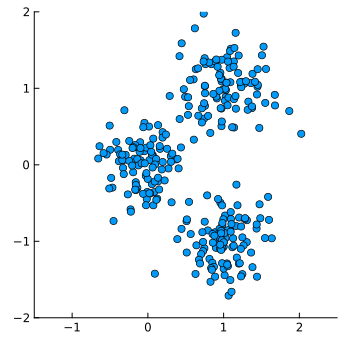

In [9]:
scatter([x[1] for x in X], [x[2] for x in X])
plot!(legend = false, grid = false, size = (350,350), xlims = (-1.5,2.5), ylims = (-2,2))

**Figure 4.1** Visualization of the 300 generated points.

Next, we apply our kmeans function and make a figure with the three clusters (Figure 4.2).

In [10]:
k = 3
#c, z = kmeans(X, k);       # The algorithm implemented in VMLS-package.
c, z, J = kmeans_(X, k);   # The version implemented above ().

Iteration 1: Jclust = 2.361910078722.
Iteration 2: Jclust = 0.586671468739616.
Iteration 3: Jclust = 0.38947750789458113.
Iteration 4: Jclust = 0.25156096661154476.
Iteration 5: Jclust = 0.18108279495625196.
Iteration 6: Jclust = 0.1756093048396566.
Iteration 7: Jclust = 0.17557108483237557.
Iteration 8: Jclust = 0.17557108483237557.


In [11]:
Jclust(X,z,c)               # The objective function value of the k-means solution (z,c).

0.17557108483237555

In [12]:
# The k cluster centers:
z

3-element Vector{Vector{Float64}}:
 [1.0214175839161843, 1.0325396879587547]
 [-0.06711847087605917, 0.0037230849882589428]
 [1.0057261778542448, -0.9953860304356218]

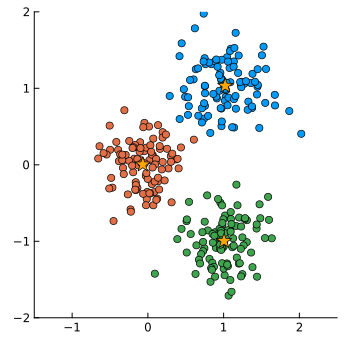

In [13]:
# Scatter plot of the clustering solution
N = length(X)
Gs = [[X[i] for i=1:N if c[i] == j] for j=1:k]
scatter()
for j = 1:k
scatter!([x[1] for x in Gs[j]], [x[2] for x in Gs[j]])
end
# Add cluster centers to the scatter plat:
scatter!([cs[1] for cs in z], [cs[2] for cs in z], marker = :star, markersize = 8, color = :orange)
plot!(legend = false, grid = false, size = (350,350), xlims = (-1.5,2.5), ylims = (-2,2))


**Figure 4.2** The final clustering

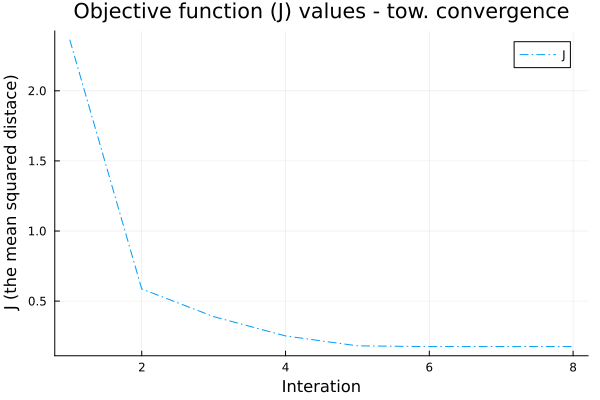

In [14]:
# Plot objective function values from clustering process
plot(J, linestyle = :dashdot, title = "Objective function (J) values - tow. convergence",
    ylabel = "J (the mean squared distace)", xlabel="Interation", grid = true, label="J")

### 4.4 Examples: Clustering handwritten images


**4.4.1 - Clustering of the [MNIST](https://en.wikipedia.org/wiki/MNIST_database) image-data** - [see & read 4.4.1, pages 79-82 in VMLS](https://web.stanford.edu/~boyd/vmls/vmls.pdf#page=89). 



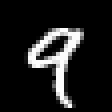

In [15]:
using MLDatasets

train_x, train_y = MNIST(split=:train)[:]; #MNIST.traindata();
test_x,  test_y  = MNIST(split=:test)[:]; #MNIST.testdata();
p1, p2, n = size(train_x) # p1 x p2 - image size, n - number of images

# We convert the training-data into vectors for clustering (where the labels will be ignored).
Xtrain = convert(Matrix{Float64}, reshape(permutedims(train_x, (3,1,2)), (n, p1*p2)));
Xtrain = [Xtrain[i,:] for i in 1:size(Xtrain,1)];
Gtrain = train_y; # The true labels of the traning data

# Display an image
using Images
Gray.(train_x[:,:,5]') #MNIST.convert2image(train_x[:,:,5])

#### Some (random) sample images

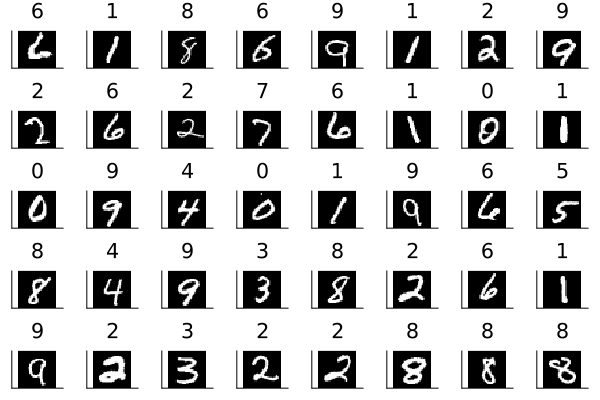

In [16]:
# Plot some (random) sample images from the MNIST-dataset
using Random

sams = 40;                       # The sample size
idsi = sort(randperm(n)[1:sams]) # Indices of the randomly selected images

plot_array = [] # For collecting images to be plotted

for k in 1:length(idsi)
    push!(plot_array, plot(Gray.(reshape(Xtrain[idsi[k]],(28,28)))', axis = nothing))
end

clb = string.(Gtrain[idsi]'); # Class labels
display(plot(plot_array..., title = clb, layout = (5,8)))

In [ ]:
# Run the k-means algorithm

kₛ = 6                         # Positive integer value to assure nice display below
k = kₛ^2;                      # the number of clusters
c, z, J = kmeans_(Xtrain, k); # k-means clustering 

Iteration 1: Jclust = 54.63478570066644.
Iteration 2: Jclust = 35.28685591198732.
Iteration 3: Jclust = 34.034355851089174.
Iteration 4: Jclust = 33.392563828119194.
Iteration 5: Jclust = 33.07329165599459.
Iteration 6: Jclust = 32.88482942977369.
Iteration 7: Jclust = 32.76748062052303.
Iteration 8: Jclust = 32.686490213744676.
Iteration 9: Jclust = 32.62633995454713.
Iteration 10: Jclust = 32.58198334680703.
Iteration 11: Jclust = 32.544622710208216.
Iteration 12: Jclust = 32.51230209585925.
Iteration 13: Jclust = 32.483110021213136.
Iteration 14: Jclust = 32.45583722215712.
Iteration 15: Jclust = 32.427559353604394.
Iteration 16: Jclust = 32.39818827476728.
Iteration 17: Jclust = 32.36981217549915.
Iteration 18: Jclust = 32.34654333407543.
Iteration 19: Jclust = 32.33045178041093.
Iteration 20: Jclust = 32.31839343933582.
Iteration 21: Jclust = 32.308372188277104.
Iteration 22: Jclust = 32.30099269897782.
Iteration 23: Jclust = 32.29505054494994.
Iteration 24: Jclust = 32.2896612764

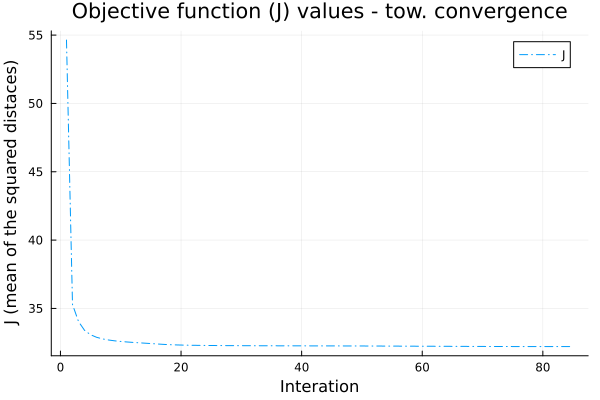

In [33]:
# Plot objective function values from clustering process
plot(J, linestyle = :dashdot, title = "Objective function (J) values - tow. convergence",
    ylabel = "J (mean of the squared distaces)", xlabel="Interation", grid = true, label="J")

#### View the Group representatives (final cluster centers)

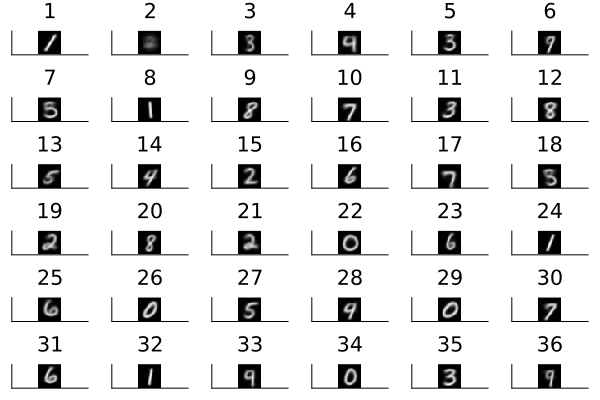

In [34]:
cluster_array = [] # For collecting cluster centers (in z) to be plotted

for k in 1:k
    push!(cluster_array, plot(Gray.(reshape(z[k],(28,28)))', axis = nothing))
end

clc = string.((1:k)'); # Cluster labels (1-25)
display(plot(cluster_array..., title = clc, layout = (kₛ,kₛ)))

We can find the __most frequently occuring__ `Gtrain`-group of each cluster as follows:

In [35]:
using StatsBase
y = [argmax(counts(Gtrain[c .== l], 0:9))-1 for l in 1:k];

Now, we can repeat the previous plot with labelling corrsponding to the most frequent group:

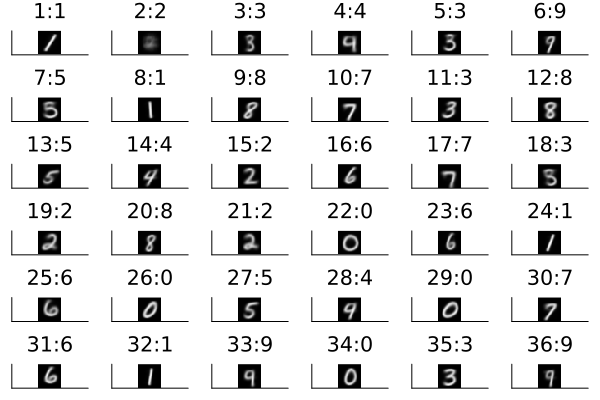

In [36]:
cluster_array = [] # For collecting cluster centers (in z) to be plotted

for k in 1:k
    push!(cluster_array, plot(Gray.(reshape(z[k],(28,28)))', axis = nothing))
end

# clc = string.(y'); # Group labels (0 - 9)
clc = string.((1:k)') .* ":" .* string.(y') # Cluster and group labels combined
display(plot(cluster_array..., title = clc, layout = (kₛ,kₛ)))

#### Nice to do (exercises): 
* Assume that we use the most frequent (digit) group of a cluster as a classification assignment: Compute the classification error and Confusion matrix for the traning data.
* Define: `Xtest = convert(Matrix{Float64}, reshape(permutedims(test_x, (3,1,2)), (m, p1*p2))); # where m = size(test_x,3);`
* Define: `Gtest = test_y; # The labels of the test-data`.
* Assign to each sample from Xtest the cluster label corresponding to the closest of the cluster centers in z (and also to the  most frequent group).
* Suggest a way to assess the goodness of the clustering by comparing the cluster assignments and the labels for both the training- and test labels.
* Finally (and maybe later): (1) We'll modify the clustering algorithm to run a repeated number of times. (2) To compare angles between vectors instead of distances.

### 4.5 More applications
[See 4.5, page 85 i VMLS](https://web.stanford.edu/~boyd/vmls/vmls.pdf#page=95).